In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler, sampler
import numpy as np
import matplotlib.colors as mcolors

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.07MB/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Epoch: 001/030 | Loss: 0.0523
Time elapsed: 4.17 min
Epoch: 002/030 | Loss: 0.0503
Time elapsed: 8.27 min
Epoch: 003/030 | Loss: 0.0479
Time elapsed: 12.36 min
Epoch: 004/030 | Loss: 0.0436
Time elapsed: 16.43 min
Epoch: 005/030 | Loss: 0.0429
Time elapsed: 20.52 min
Epoch: 006/030 | Loss: 0.0449
Time elapsed: 24.58 min
Epoch: 007/030 | Loss: 0.0447
Time elapsed: 28.59 min
Epoch: 008/030 | Loss: 0.0417
Time elapsed: 32.68 min
Epoch: 009/030 | Loss: 0.0460
Time elapsed: 36.76 min
Epoch: 010/030 | Loss: 0.0447
Time elapsed: 41.44 min
Epoch: 011/030 | Loss: 0.0406
Time elapsed: 45.55 min
Epoch: 012/030 | Loss: 0.0423
Time elapsed: 49.68 min
Epoch: 013/030 | Loss: 0.0459
Time elapsed: 53.83 min
Epoch: 014/030 | Loss: 0.0417
Time elapsed: 57.94 min
Epoch: 015/030 | Loss: 0.0405
Time elapsed: 62.01 min
Epoch: 016/030 | Loss: 0.0424
Time elapsed: 66.13 min
Epoch: 017/030 | Loss: 0.0425
Time elapsed: 70.21 min
Epoch: 018/03

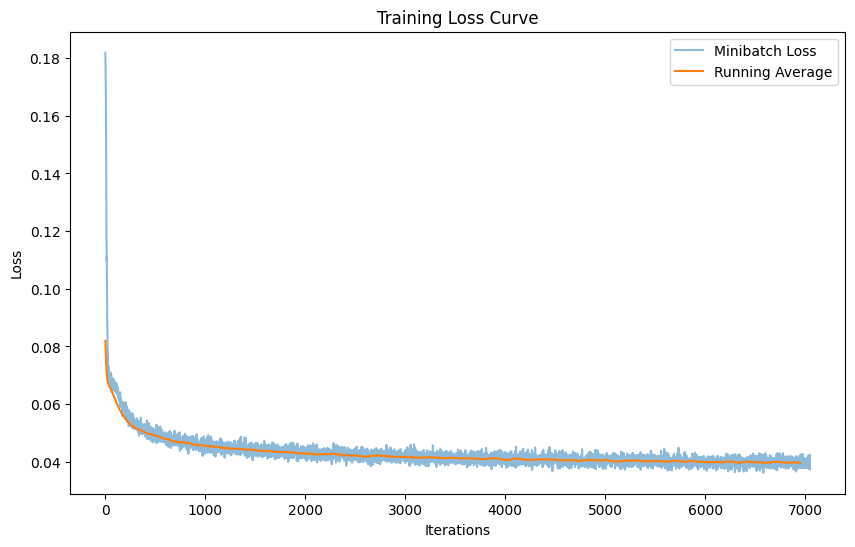

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler, sampler
import numpy as np
import matplotlib.colors as mcolors

# Hyperparameters

RANDOM_SEED = 49
LEARNING_RATE = 0.0005
BATCH_SIZE = 256
NUM_EPOCHS = 30
NUM_CLASSES = 10



def get_dataloaders_mnist(batch_size, num_workers=0, train_transforms=None, test_transforms=None):
    if train_transforms is None:
        train_transforms = transforms.ToTensor()
    if test_transforms is None:
        test_transforms = transforms.ToTensor()

    train_dataset = datasets.MNIST(root='data', train=True, transform=train_transforms, download=True)
    test_dataset = datasets.MNIST(root='data', train=False, transform=test_transforms)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    return train_loader, test_loader

class Trim(nn.Module):
    def forward(self, x):
        # Crop the tensor to remove 1 pixel from the right and bottom
        return x[:, :, :-1, :-1]

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=1),
            nn.Flatten(),
            nn.Linear(3136, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 3136),
            nn.Unflatten(-1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=0),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=0),
            Trim(),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x





def compute_epoch_loss_autoencoder(model, data_loader, loss_fn):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    num_batches = 0

    with torch.no_grad():  # Disable gradient calculations
        for features, _ in data_loader:
            # Forward pass
            logits = model(features)
            loss = loss_fn(logits, features)

            # Accumulate loss
            total_loss += loss.item()
            num_batches += 1

    # Compute average loss over all batches
    avg_loss = total_loss / num_batches
    return avg_loss


def train_autoencoder(num_epochs, model, optimizer, train_loader, loss_fn=None, logging_interval=100, skip_epoch_stats=False, save_model=None):
    log_dict = {'train_loss_per_batch': [],
                'train_loss_per_epoch': []}

    if loss_fn is None:
        loss_fn = F.mse_loss

    start_time = time.time()
    minibatch_losses = []

    for epoch in range(num_epochs):
        model.train()

        for batch_idx, (features, _) in enumerate(train_loader):
            logits = model(features)
            loss = loss_fn(logits, features)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            minibatch_losses.append(loss.item())

        print('Epoch: %03d/%03d | Loss: %.4f' % (epoch+1, num_epochs, loss.item()))

        if not skip_epoch_stats:
            model.eval()
            with torch.set_grad_enabled(False):         # save memory during inference
                train_loss = compute_epoch_loss_autoencoder(model, train_loader, loss_fn)
                print('***Epoch: %03d/%03d | Loss: %.3f' % (epoch+1, num_epochs, train_loss))
                log_dict['train_loss_per_epoch'].append(train_loss.item())
        print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))
    if save_model is not None:
        torch.save(model.state_dict(), save_model)
    plot_loss_curve(minibatch_losses, running_avg_window=100)
    return log_dict

def plot_loss_curve(minibatch_losses, running_avg_window=100):
    plt.figure(figsize=(10, 6))

    # Compute running average
    running_avg = np.convolve(minibatch_losses, np.ones(running_avg_window)/running_avg_window, mode='valid')

    # Plot minibatch loss
    plt.plot(range(len(minibatch_losses)), minibatch_losses, label='Minibatch Loss', color='tab:blue', alpha=0.5)

    # Plot running average
    plt.plot(range(len(running_avg)), running_avg, label='Running Average', color='tab:orange')

    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Loss Curve')
    plt.show()




if __name__ == '__main__':
    train_loader, test_loader = get_dataloaders_mnist(
        batch_size=BATCH_SIZE,
        num_workers=2
        )

    model = AutoEncoder()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
        )

    log_dict = train_autoencoder(
        num_epochs=NUM_EPOCHS,
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        skip_epoch_stats=True,
        logging_interval=250
        )